# NYC Airbnb 2019 — Exploratory Data Analysis

This notebook performs exploratory data analysis on the **New York City Airbnb Open Data (2019)** dataset.

### Objectives
- Understand the structure of the dataset
- Check data quality and missing values
- Analyse room types and neighbourhood groups
- Explore numerical variables
- Study price distribution across room types
- Analyse correlations between numerical variables
- Understand the geographical distribution of Airbnb listings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

Load the Airbnb dataset into a Pandas DataFrame so that we can begin the exploratory data analysis.


In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

## 2. Preview the Dataset

Use `head()` to view the first few rows and understand how the data is organised.


In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Dataset Dimensions

Check the number of rows and columns in the dataset using `shape`.


In [4]:
df.shape

(48895, 16)

## 4. Dataset Information

Use `info()` to inspect:
- Number of entries
- Column names
- Data types
- Non-null values


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## 5. Missing Value Analysis

Check which columns contain missing values.

This helps us identify columns that may require data cleaning before further analysis.


In [6]:
missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

## 6. Duplicate Value Analysis

Check whether the dataset contains duplicate rows.

Duplicate records can affect the accuracy of our analysis, so they should be identified before continuing.


In [7]:
df.duplicated().sum()

np.int64(0)

## 7. Room Type Distribution

Analyse the number of listings available for each `room_type`.

This helps us understand which type of Airbnb accommodation is most common in NYC.


In [8]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

### Visualisation — Room Type Distribution

Visualise the distribution of Airbnb listings across different room types.


<Axes: xlabel='room_type', ylabel='count'>

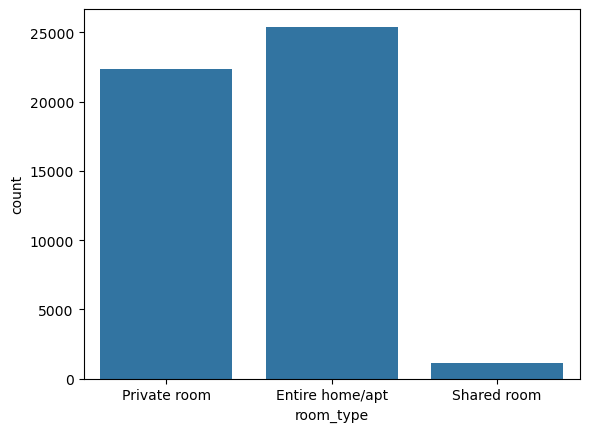

In [9]:
sns.countplot(x=df["room_type"] , data=df)

## 8. Explore Dataset Columns

Display all column names to understand which variables are available for further analysis.


In [10]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

## 9. Numerical Variable Analysis

Select important numerical variables for exploratory analysis:

- `price`
- `minimum_nights`
- `number_of_reviews`
- `reviews_per_month`
- `calculated_host_listings_count`
- `availability_365`

Histograms are used to understand the distribution of these numerical variables.


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

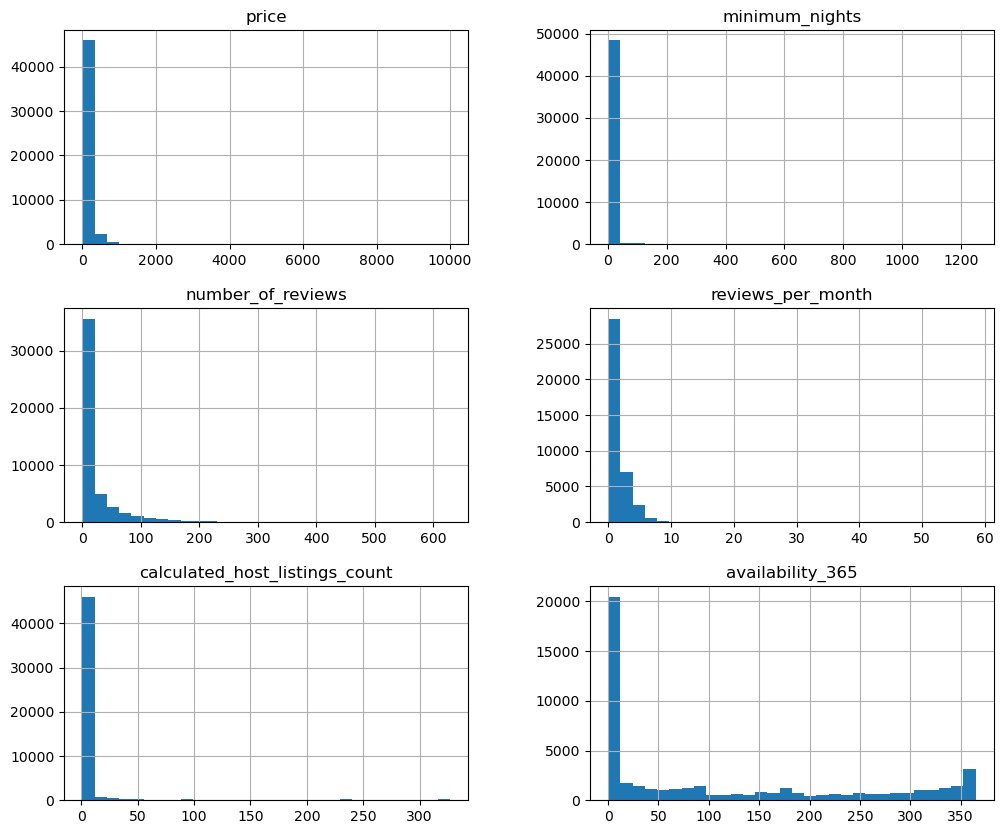

In [11]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365' ]



df[numeric_cols].hist(bins=30, figsize=(12, 10))

## 10. Neighbourhood Group Analysis

Analyse the distribution of Airbnb listings across NYC's neighbourhood groups.

This helps us identify which neighbourhood groups contain the largest number of listings.


<Axes: xlabel='neighbourhood_group', ylabel='count'>

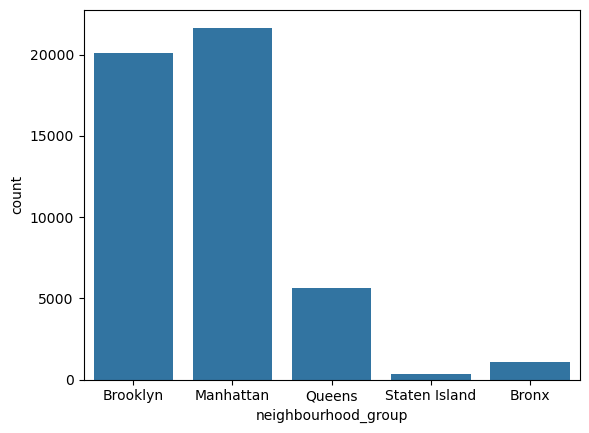

In [12]:
cat_col = df.select_dtypes(include='object').columns


sns.countplot(data=df, x="neighbourhood_group")

## 11. Price Analysis by Room Type

Compare Airbnb prices across different room types using a box plot.

This helps us understand:
- The typical price range for each room type
- Differences in pricing
- Possible outliers


<Axes: xlabel='room_type', ylabel='price'>

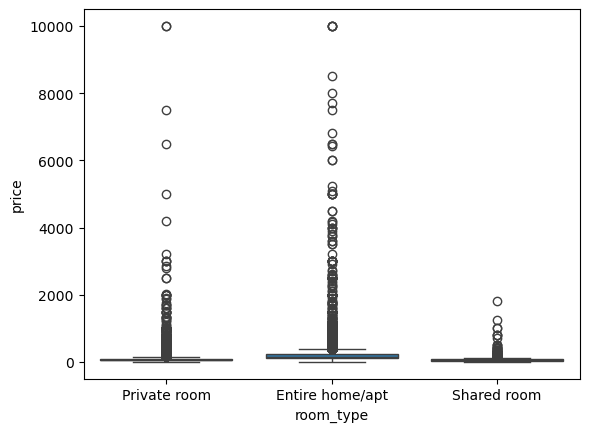

In [13]:
sns.boxplot(x="room_type", y="price", data=df)

<Axes: xlabel='room_type', ylabel='minimum_nights'>

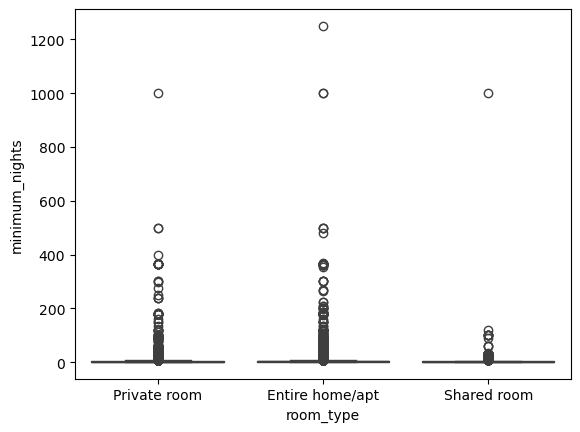

In [14]:
sns.boxplot(x="room_type", y="minimum_nights", data=df)

## 12. Correlation Analysis

Calculate the correlation between numerical variables.

A correlation close to:
- `+1` indicates a strong positive relationship
- `0` indicates little or no linear relationship
- `-1` indicates a strong negative relationship

The heatmap makes these relationships easier to compare.


<Axes: >

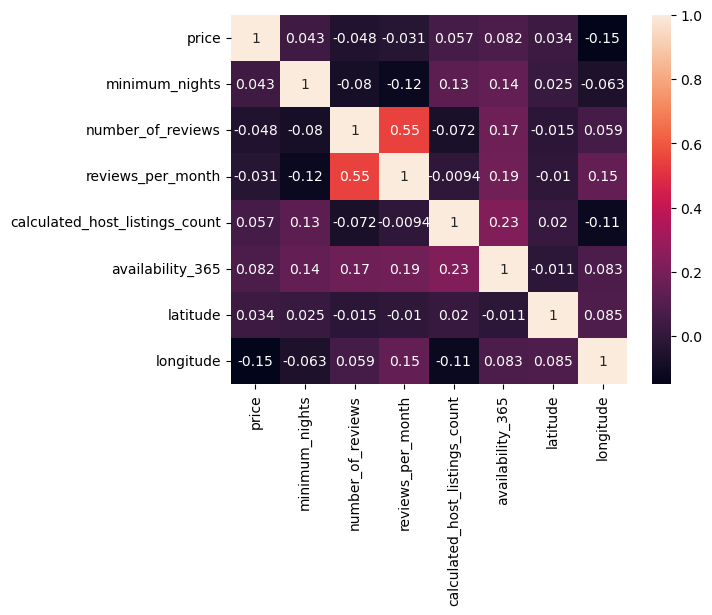

In [15]:
corr = df[numeric_cols + ['latitude', 'longitude']].corr()

sns.heatmap(corr, annot=True)

## 13. Geographical Distribution of Listings

Use the `latitude` and `longitude` columns to visualise where Airbnb listings are located across NYC.

The colour grouping represents different room types, allowing us to compare their geographical distribution.


<Axes: xlabel='longitude', ylabel='latitude'>

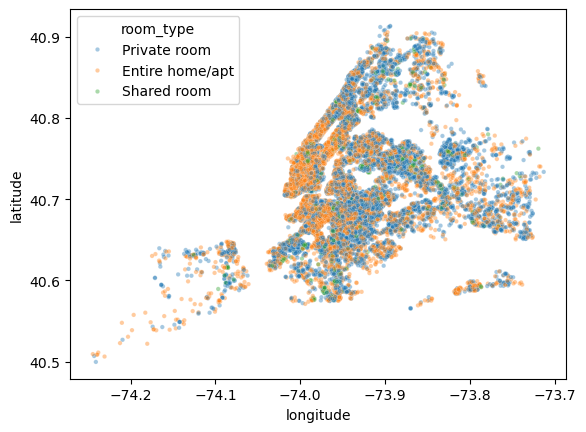

In [16]:
sns.scatterplot(x="longitude", y="latitude", data=df, hue="room_type", alpha=0.4, s=10)

# Conclusion

In this EDA, we explored the NYC Airbnb 2019 dataset by examining:

- Dataset structure and dimensions
- Missing and duplicate values
- Room type distribution
- Neighbourhood group distribution
- Numerical variable distributions
- Price differences between room types
- Correlations between numerical variables
- Geographical distribution of Airbnb listings

The next step can be to extract the **key insights and observations** from each analysis.


# Machine Learning — Room Type Classification

After completing the exploratory data analysis, we now build a machine learning model to predict the `room_type` of an Airbnb listing.

Since `room_type` is a categorical target variable, this is a **classification problem**.


## 14. Data Cleaning and Feature Preparation

Remove columns that are not useful for prediction.

- `id`, `host_id` are identifiers.
- `name`, `host_name` are high-cardinality text fields.
- `last_review` is not used in this model.

For `reviews_per_month`, missing values are replaced with `0` because a listing with no reviews can reasonably have zero reviews per month.


In [17]:
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name','last_review']) # drop unneccsary columns
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0) # fill with 0 beacuse no review yet

## 15. Outlier Capping

Extreme values can strongly affect model training.

Here, the 99th percentile is used as an upper cap for:

- `price`
- `minimum_nights`

Values above the calculated cap are replaced by the cap value.


In [18]:
price_cap = df_clean["price"].quantile(0.99)
nights_cap = df_clean["minimum_nights"].quantile(0.99)

df_clean["price"] = df_clean["price"].clip(upper=price_cap)
df_clean["minimum_nights"] = df_clean["minimum_nights"].clip(upper=nights_cap)

## 16. Define Features and Target

The target variable is `room_type`.

- `X` contains the input features.
- `y` contains the target classes that the model will predict.


In [19]:
X = df_clean.drop(columns=["room_type"])
y = df_clean["room_type"]

## 17. Train-Test Split

Split the dataset into training and testing sets.

`stratify=y` keeps the class distribution approximately similar in both sets, which is useful for a classification problem.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

## 18. Check the Cleaned Dataset Columns

Review the available columns after removing unnecessary features.


In [21]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

## 19. Define Numerical and Categorical Features

Separate the input features into two groups:

**Numerical features**
- latitude
- longitude
- price
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count
- availability_365

**Categorical features**
- neighbourhood_group
- neighbourhood

Different preprocessing is required for numerical and categorical data.


In [22]:
numeric_cols = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']


cat_cols = ['neighbourhood_group', 'neighbourhood']

## 20. Check Skewness of Numerical Features

Calculate skewness to understand whether numerical variables have highly asymmetric distributions.

This helps decide whether a transformation such as Yeo-Johnson may be useful.


In [23]:
df_clean[numeric_cols].skew()

latitude                          0.237167
longitude                         1.284210
price                             2.776321
minimum_nights                    2.360347
number_of_reviews                 3.690635
reviews_per_month                 3.300723
calculated_host_listings_count    7.933174
availability_365                  0.763408
dtype: float64

## 21. Import Preprocessing Tools

We will use:

- `SimpleImputer` for missing values
- `PowerTransformer` for reducing skewness
- `StandardScaler` for scaling numerical features
- `OneHotEncoder` for categorical features
- `ColumnTransformer` to apply different preprocessing to different columns
- `Pipeline` to combine preprocessing steps with the model


In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 22. Build the Preprocessing Pipelines

### Numerical pipeline

1. Fill missing values using the median.
2. Apply the Yeo-Johnson transformation.
3. Standardize the numerical features.

### Categorical pipeline

1. Fill missing values using the most frequent category.
2. Convert categorical values into numerical features using one-hot encoding.

`handle_unknown="ignore"` allows the model to handle categories that were not present during training.


In [25]:
# 1. Pipeline --> Numerics Col
numeric_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("skewness", PowerTransformer(method="yeo-johnson")),
    ("scaler" , StandardScaler())
])

# 2. Pipeline --> Categorical Col
categorical_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encoder" , OneHotEncoder(handle_unknown="ignore"))
])


# preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ("numeric_cols", numeric_pipeline, numeric_cols),
    ("categorical_cols", categorical_pipeline, cat_cols)
])

preprocessor

,transformers,"[('numeric_cols', ...), ('categorical_cols', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 23. Suppress Unnecessary Warnings

Warnings are suppressed to keep the notebook output easier to read while running multiple models and preprocessing steps.


In [26]:
import warnings
warnings.filterwarnings('ignore')

## 24. Define Classification Models

We compare several classification algorithms:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The preprocessing pipeline is combined with each classifier so that preprocessing is performed correctly inside cross-validation.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

## 25. Compare Models Using Cross-Validation

Each model is evaluated using 3-fold cross-validation.

Two metrics are considered:

- **Accuracy** — proportion of correctly classified samples.
- **F1 Macro** — calculates the F1-score for each class and gives every class equal importance.

F1 Macro is particularly useful when class distributions are not perfectly balanced.


In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree" : DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest" : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor), 
        ("classifier", model)
    ])




    
    # Accuracy alone can be misleading on imbalanced classes, so we can use micro f1
    # both: plain accuracy and f1 macro (which treats every class equally)
    
    accuracy = cross_val_score(pipe, X_train, y_train, cv=3, scoring="accuracy")
    f1_macro = cross_val_score(pipe, X_train, y_train, cv=3, scoring="f1_macro")

    print(f"{name} ---> Accuracy : {accuracy.mean():.3f}, f1_macro: {f1_macro.mean():.3f}")

## 26. Hyperparameter Tuning with RandomizedSearchCV

RandomizedSearchCV searches through randomly selected combinations of hyperparameters instead of testing every possible combination.

Here, Random Forest is selected for further tuning.

The search optimizes **F1 Macro**, using 3-fold cross-validation.

Parameters being tuned include:

- `n_estimators`
- `max_depth`
- `min_samples_split`


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced"))
])

param_distribution = {
    "classifier__n_estimators": [100, 200, 150, 300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}


search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
)

search.fit(X_train, y_train)

## 27. Best Hyperparameters

Display the hyperparameter combination that achieved the best cross-validation F1 Macro score.


In [ ]:
print("Best Parameters :- ", search.best_params_)
print("Best CV Macro-f1 :- ", search.best_score_)

## 28. Evaluate the Final Model on the Test Set

Use the best estimator found by RandomizedSearchCV to make predictions on unseen test data.

The final model is evaluated using:

- Accuracy
- Confusion Matrix
- F1 Macro


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score
best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print("Accuracy Score :- ", accuracy_score(y_test, y_pred))
print("Confusion matrix :- ", confusion_matrix(y_test, y_pred))
print("f1_score :- ", f1_score(y_test, y_pred , average="macro"))


## 29. Confusion Matrix Visualization

Visualize the confusion matrix to understand how well the model distinguishes between the different `room_type` classes.


In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f", xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

## 30. Save the Complete Model Pipeline

Save the fitted pipeline using `joblib`.

The saved pipeline contains both:

- preprocessing steps
- the trained Random Forest classifier

This makes the model suitable for later loading and deployment.


In [ ]:
# Saving the model

import joblib
joblib.dump(best_pipeline, "Model_pipeline.pkl")

# Final Conclusion

This notebook started with exploratory data analysis of the NYC Airbnb 2019 dataset and then developed a machine learning classification model to predict `room_type`.

### Workflow

1. Loaded and explored the dataset.
2. Analysed missing values and duplicates.
3. Explored room types, neighbourhoods, prices and numerical variables.
4. Cleaned unnecessary columns.
5. Prepared numerical and categorical features.
6. Built preprocessing pipelines.
7. Compared multiple classification models.
8. Used RandomizedSearchCV to tune Random Forest hyperparameters.
9. Evaluated the final model using Accuracy, F1 Macro and a Confusion Matrix.
10. Saved the complete fitted pipeline for deployment.
